# Credit Risk Analysis — Phase 2: Feature Engineering
**Goal:** Create new meaningful features that improve model performance
**Key idea:** Engineer domain-specific features banks actually use

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

df = pd.read_csv('data_clean.csv')
print('Clean data loaded:', df.shape)
df.head()

Clean data loaded: (149377, 12)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_group
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,35-45
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,35-45
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,35-45
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,25-35
4,0,0.907239,49,1,0.024926,17900.0,7,0,1,0,0.0,45-55


## Feature Engineering

In [2]:
df_feat = df.copy()

# Feature 1: Debt-to-Income Ratio
df_feat['DebtToIncomeRatio'] = df_feat['DebtRatio'] * df_feat['MonthlyIncome'] / (df_feat['MonthlyIncome'] + 1)

# Feature 2: Income per Dependent
df_feat['IncomePerDependent'] = df_feat['MonthlyIncome'] / (df_feat['NumberOfDependents'] + 1)

# Feature 3: Total Late Payments
df_feat['TotalLatePayments'] = (df_feat['NumberOfTime30-59DaysPastDueNotWorse'] +
                                 df_feat['NumberOfTime60-89DaysPastDueNotWorse'] +
                                 df_feat['NumberOfTimes90DaysLate'])

# Feature 4: Weighted Late Payment Score
df_feat['WeightedLateScore'] = (df_feat['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
                                 df_feat['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
                                 df_feat['NumberOfTimes90DaysLate'] * 3)

# Feature 5: Credit Utilization Category
df_feat['UtilizationCategory'] = pd.cut(
    df_feat['RevolvingUtilizationOfUnsecuredLines'],
    bins=[-0.01, 0.3, 0.6, 0.8, 1.01],
    labels=[0, 1, 2, 3]
).astype(float)

# Feature 6: Has Any Late Payment
df_feat['HasLatePayment'] = (df_feat['TotalLatePayments'] > 0).astype(int)

new_features = ['DebtToIncomeRatio', 'IncomePerDependent', 'TotalLatePayments',
                'WeightedLateScore', 'UtilizationCategory', 'HasLatePayment']

print('New features created:')
print(df_feat[new_features].describe().round(2))

New features created:
       DebtToIncomeRatio  IncomePerDependent  TotalLatePayments  \
count          149377.00           149377.00          149377.00   
mean                0.85             4377.57               0.84   
std                 1.07             3025.97              11.43   
min                 0.00                0.00               0.00   
25%                 0.17             2150.00               0.00   
50%                 0.36             4000.00               0.00   
75%                 0.81             5400.00               0.00   
max                 2.97            17900.00             294.00   

       WeightedLateScore  UtilizationCategory  HasLatePayment  
count          149377.00            149377.00        149377.0  
mean                1.53                 0.78             0.2  
std                22.86                 1.14             0.4  
min                 0.00                 0.00             0.0  
25%                 0.00                 0.00         

## Visualize New Features vs Default Rate

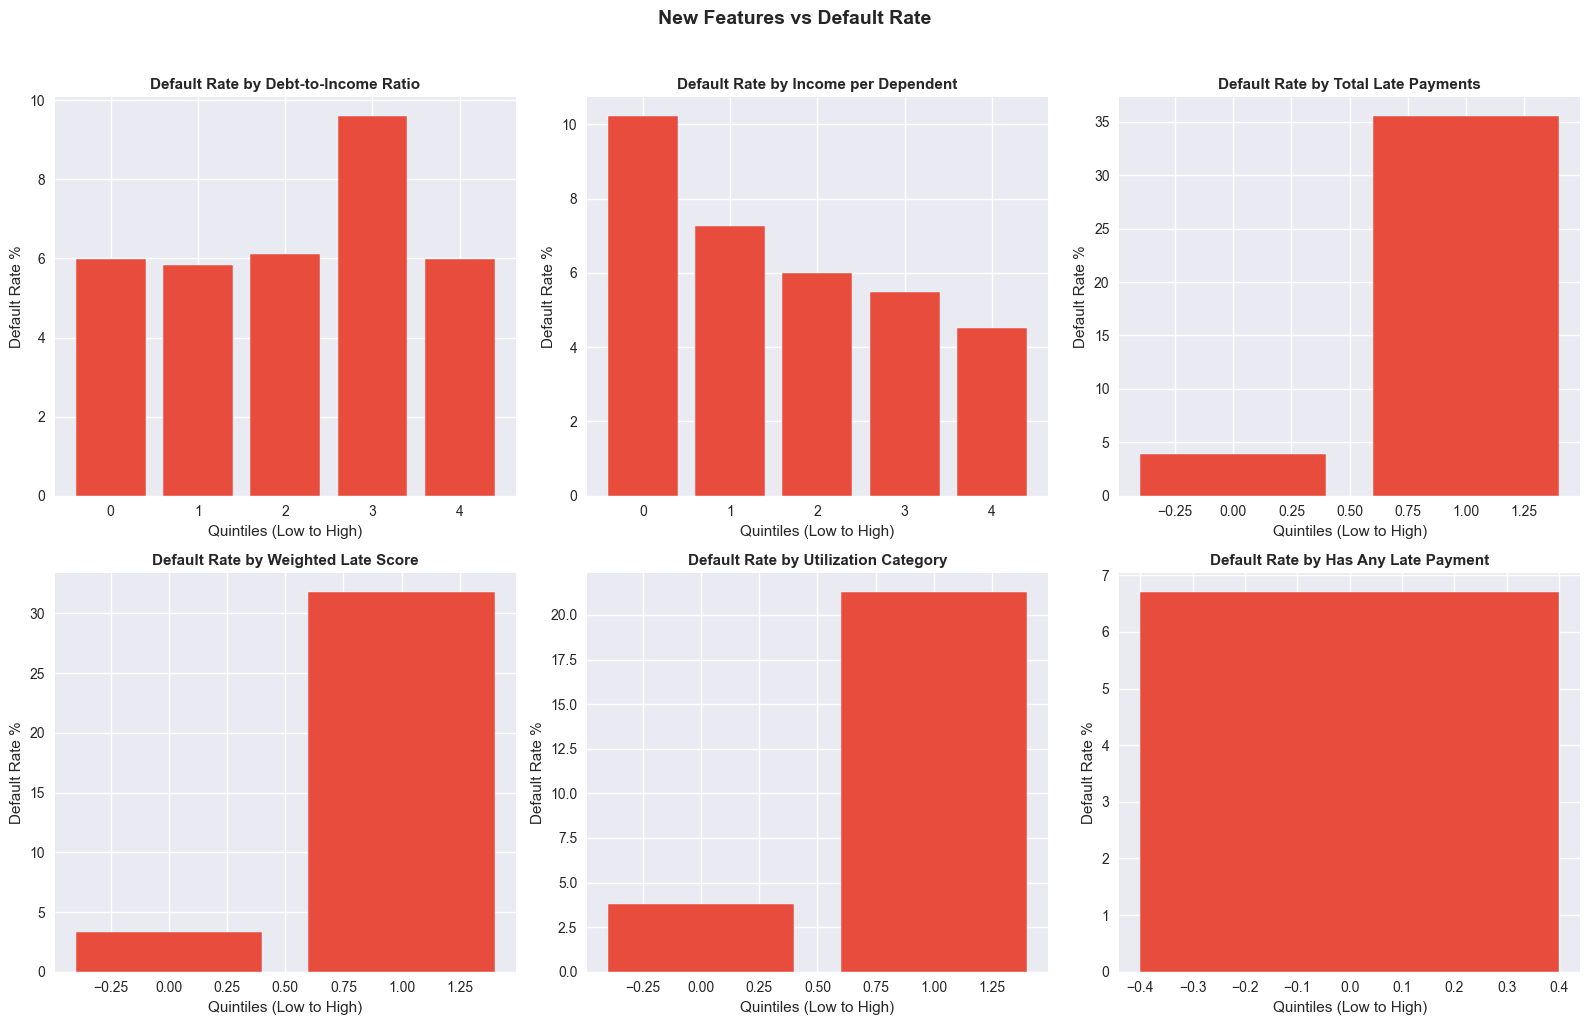

INSIGHT: Higher late payment values strongly predict default.


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feature_titles = [
    'Debt-to-Income Ratio',
    'Income per Dependent',
    'Total Late Payments',
    'Weighted Late Score',
    'Utilization Category',
    'Has Any Late Payment'
]

for i, (feat, title) in enumerate(zip(new_features, feature_titles)):
    default_rate = df_feat.groupby(
        pd.qcut(df_feat[feat], q=5, duplicates='drop'), observed=True
    )['SeriousDlqin2yrs'].mean() * 100
    axes[i].bar(range(len(default_rate)), default_rate.values, color='#e74c3c', edgecolor='white')
    axes[i].set_title(f'Default Rate by {title}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Default Rate %')
    axes[i].set_xlabel('Quintiles (Low to High)')

plt.suptitle('New Features vs Default Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/06_feature_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

print('INSIGHT: Higher late payment values strongly predict default.')

## Prepare Final Feature Set

In [4]:
df_model = df_feat.drop(columns=['age_group'])

feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'DebtToIncomeRatio',
    'IncomePerDependent',
    'TotalLatePayments',
    'WeightedLateScore',
    'UtilizationCategory',
    'HasLatePayment'
]

target_col = 'SeriousDlqin2yrs'

X = df_model[feature_cols]
y = df_model[target_col]

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]:,}')
print(f'Default rate: {y.mean()*100:.1f}%')

print('\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2}. {col}')

Features: 16
Samples:  149,377
Default rate: 6.7%

Feature list:
   1. RevolvingUtilizationOfUnsecuredLines
   2. age
   3. NumberOfTime30-59DaysPastDueNotWorse
   4. DebtRatio
   5. MonthlyIncome
   6. NumberOfOpenCreditLinesAndLoans
   7. NumberOfTimes90DaysLate
   8. NumberRealEstateLoansOrLines
   9. NumberOfTime60-89DaysPastDueNotWorse
  10. NumberOfDependents
  11. DebtToIncomeRatio
  12. IncomePerDependent
  13. TotalLatePayments
  14. WeightedLateScore
  15. UtilizationCategory
  16. HasLatePayment


In [5]:
df_model[feature_cols + [target_col]].to_csv('data_features.csv', index=False)
print('Feature data saved to data_features.csv')

Feature data saved to data_features.csv
